In [1]:
import pandas as pd 
import os
import sys
import matplotlib.pyplot as plt
from PIL import Image
import torch
import numpy as np
import seaborn as sns

In [2]:
plt.rcParams.update({
    'font.size': 17,
    'axes.linewidth': 1.2,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
})

In [3]:
def load_image(relative_path, base_dir, device):
    """Load a CheXpert image into the [-1,1] format that Nina's pipeline expects."""
    full_path = os.path.join(base_dir, "data/CheXpert-v1.0-small/train/", relative_path)
    img = Image.open(full_path).convert('L')        # grayscale
    img = img.resize((224, 224), Image.LANCZOS)
    img_np = np.array(img).astype(np.float32) / 255.0
    img_t  = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0)  # (1,1,224,224)
    img_t  = img_t * 2.0 - 1.0                      # [0,1] → [-1,1]
    return img_t.to(device)


In [4]:
shortcuts_nina_path = "/zhome/d0/a/221493/thesis/data/che_pm_shortcut_labels.csv"
shortcuts_nina = pd.read_csv(shortcuts_nina_path)
shortcuts_nina

chexpert_data_path = "/zhome/d0/a/221493/thesis/data/CheXpert-v1.0-small/train.csv"
chexpert_data =  pd.read_csv(chexpert_data_path)

In [5]:
# Print samole with PM = 0 and PM = 1
print(shortcuts_nina[shortcuts_nina["PM"] == 0].sample(5))
print(shortcuts_nina[shortcuts_nina["PM"] == 1].sample(5))

                                    img_name  Cardiomegaly  PM  split
14740  patient37731_study2_view1_frontal.jpg             0   0  train
21529  patient43582_study4_view1_frontal.jpg             0   0  train
20113  patient44370_study4_view1_frontal.jpg             0   0  train
21520  patient46096_study2_view1_frontal.jpg             0   0  train
13460  patient47820_study1_view1_frontal.jpg             0   0  train
                                   img_name  Cardiomegaly  PM  split
956   patient43443_study1_view1_frontal.jpg             1   1   test
7547  patient32409_study1_view1_frontal.jpg             0   1   test
797   patient26435_study9_view1_frontal.jpg             1   1  train
217   patient36760_study5_view1_frontal.jpg             1   1  train
6995  patient40706_study6_view1_frontal.jpg             0   1  train


In [6]:
def convert_img_name_to_path(img_name):
    parts = img_name.split("_")
    patient_id = parts[0]
    study_id = parts[1]
    view_id = "_".join(parts[2:])  # join the remaining parts for the view
    return f"{patient_id}/{study_id}/{view_id}"

# test
print(convert_img_name_to_path("patient43182_study1_view1_frontal.jpg"))

patient43182/study1/view1_frontal.jpg


In [7]:
# UYse load image function to load an image and print its shape
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_path = convert_img_name_to_path(shortcuts_nina.iloc[0]["img_name"])
img_tensor = load_image(img_path, "/zhome/d0/a/221493/thesis", device)
print("Loaded image tensor shape:", img_tensor.shape)

Loaded image tensor shape: torch.Size([1, 1, 224, 224])


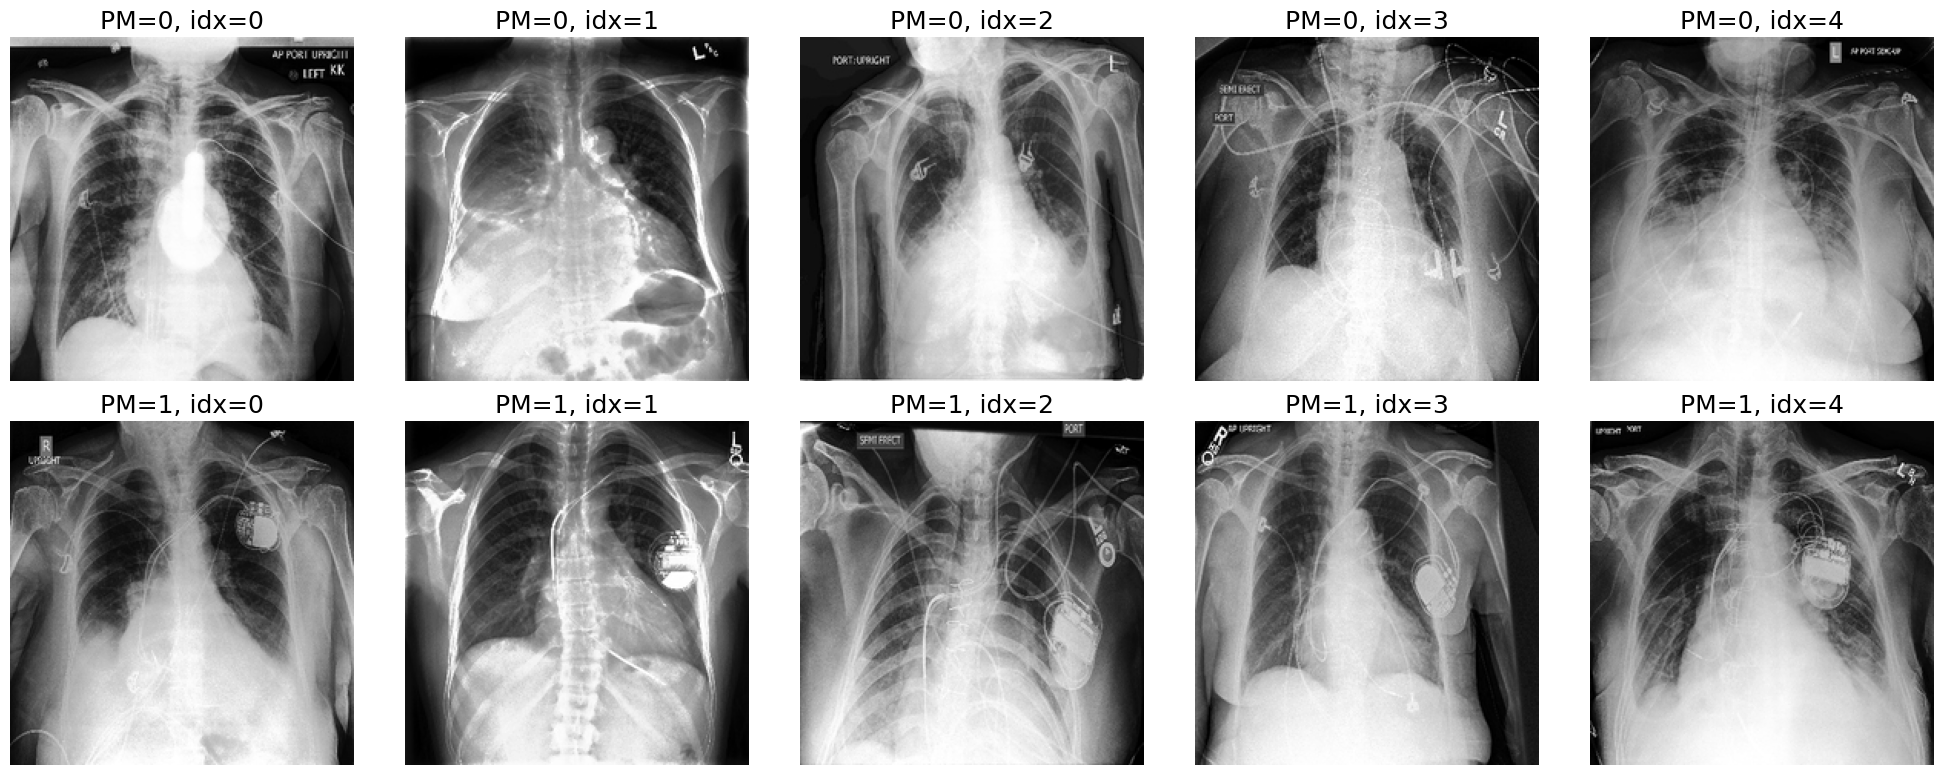

In [8]:
# Load 5 images with PM = 0 and 5 images with PM = 1, and print in a grid
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i in range(5):
    img_path_0 = convert_img_name_to_path(shortcuts_nina[shortcuts_nina["PM"] == 0].iloc[i]["img_name"])
    img_tensor_0 = load_image(img_path_0, "/zhome/d0/a/221493/thesis", device)
    img_np_0 = ((img_tensor_0.cpu().numpy().squeeze() + 1.0) / 2.0 * 255).astype(np.uint8)
    axes[0, i].imshow(img_np_0, cmap='gray')
    axes[0, i].set_title(f"PM=0, idx={i}")
    axes[0, i].axis('off')  
    img_path_1 = convert_img_name_to_path(shortcuts_nina[shortcuts_nina["PM"] == 1].iloc[i]["img_name"])
    img_tensor_1 = load_image(img_path_1, "/zhome/d0/a/221493/thesis", device)
    img_np_1 = ((img_tensor_1.cpu().numpy().squeeze() + 1.0) / 2.0 * 255).astype(np.uint8)
    axes[1, i].imshow(img_np_1, cmap='gray')
    axes[1, i].set_title(f"PM=1, idx={i}")
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [9]:
#- How many images of the ninas'cv are the same as the ones i have in chexperts train set
ninas_image_ids = set(shortcuts_nina["img_name"].apply(lambda x: convert_img_name_to_path(x)))
my_data_image_ids = set(chexpert_data["Path"].apply(lambda x: x.replace("CheXpert-v1.0-small/train/", "")))

In [10]:
print(len(ninas_image_ids))
print(len(my_data_image_ids))

28878
223414


In [11]:
print(list(ninas_image_ids)[0:10])
print(list(my_data_image_ids)[0:10])

['patient24588/study10/view1_frontal.jpg', 'patient10517/study2/view1_frontal.jpg', 'patient48600/study1/view1_frontal.jpg', 'patient21498/study1/view1_frontal.jpg', 'patient15611/study1/view1_frontal.jpg', 'patient18798/study3/view1_frontal.jpg', 'patient25842/study1/view1_frontal.jpg', 'patient23243/study1/view1_frontal.jpg', 'patient35982/study2/view1_frontal.jpg', 'patient22388/study2/view1_frontal.jpg']
['patient49096/study1/view1_frontal.jpg', 'patient30337/study25/view1_frontal.jpg', 'patient39884/study3/view1_frontal.jpg', 'patient42059/study8/view1_frontal.jpg', 'patient13684/study1/view1_frontal.jpg', 'patient08591/study2/view1_frontal.jpg', 'patient35100/study7/view1_frontal.jpg', 'patient31196/study5/view1_frontal.jpg', 'patient01945/study5/view1_frontal.jpg', 'patient09251/study1/view2_lateral.jpg']


In [12]:
# Find the intersection of the two sets
intersection = ninas_image_ids.intersection(my_data_image_ids)
print(f"Number of overlapping images: {len(intersection)}") 
print("Number of non-overlapping images in Nina's CV:", len(ninas_image_ids - intersection))
print("Number of non-overlapping images in my dataset:", len(my_data_image_ids - intersection))

Number of overlapping images: 28878
Number of non-overlapping images in Nina's CV: 0
Number of non-overlapping images in my dataset: 194536


In [13]:
chexpert_data

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223409,CheXpert-v1.0-small/train/patient64537/study2/...,Male,59,Frontal,AP,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,-1.0,0.0,1.0,NaN,NaN,NaN
223410,CheXpert-v1.0-small/train/patient64537/study1/...,Male,59,Frontal,AP,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,0.0,-1.0,NaN,-1.0,NaN,NaN,NaN
223411,CheXpert-v1.0-small/train/patient64538/study1/...,Female,0,Frontal,AP,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223412,CheXpert-v1.0-small/train/patient64539/study1/...,Female,0,Frontal,AP,NaN,NaN,1.0,1.0,NaN,NaN,NaN,-1.0,1.0,0.0,NaN,NaN,NaN,0.0


In [14]:
shortcuts_nina

,img_name,Cardiomegaly,PM,split
0,patient41055_study2_view1_frontal.jpg,1,1,train
1,patient11922_study3_view1_frontal.jpg,1,1,train
2,patient14928_study3_view1_frontal.jpg,1,1,train
3,patient04804_study4_view1_frontal.jpg,1,1,train
4,patient46597_study2_view1_frontal.jpg,1,1,train
...,...,...,...,...
28873,patient25956_study1_view1_frontal.jpg,0,0,test
28874,patient18092_study1_view1_frontal.jpg,0,0,test
28875,patient29186_study7_view1_frontal.jpg,0,0,test
28876,patient17297_study1_view1_frontal.jpg,0,0,test


In [15]:
# Create new df merged by Path with coluns : Path, Effusion, PM 
merged_df = merged_df = pd.merge(chexpert_data, shortcuts_nina, left_on=chexpert_data["Path"].apply(lambda x: x.replace("CheXpert-v1.0-small/train/", "")), right_on=shortcuts_nina["img_name"].apply(lambda x: convert_img_name_to_path(x)), how="inner")

print(merged_df.head())

                                   key_0  \
0  patient00001/study1/view1_frontal.jpg   
1  patient00002/study1/view1_frontal.jpg   
2  patient00004/study1/view1_frontal.jpg   
3  patient00005/study2/view2_frontal.jpg   
4  patient00006/study1/view1_frontal.jpg   

                                                Path     Sex  Age  \
0  CheXpert-v1.0-small/train/patient00001/study1/...  Female   68   
1  CheXpert-v1.0-small/train/patient00002/study1/...  Female   83   
2  CheXpert-v1.0-small/train/patient00004/study1/...  Female   20   
3  CheXpert-v1.0-small/train/patient00005/study2/...    Male   33   
4  CheXpert-v1.0-small/train/patient00006/study1/...  Female   42   

  Frontal/Lateral AP/PA  No Finding  Enlarged Cardiomediastinum  \
0         Frontal    AP         1.0                         NaN   
1         Frontal    AP         NaN                         NaN   
2         Frontal    PA         1.0                         0.0   
3         Frontal    AP         NaN                 

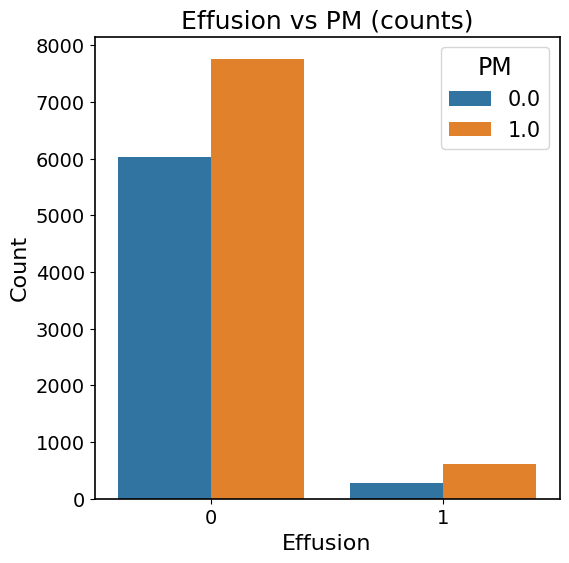

In [16]:
clean_df = merged_df.dropna(subset=["Pleural Effusion"])
clean_df = clean_df[clean_df["Pleural Effusion"] != -1]

plt.figure(figsize=(6, 6))
sns.countplot(data=clean_df, x="PM", hue="Pleural Effusion")
plt.title("Effusion vs PM (counts)")
plt.xlabel("Effusion")
plt.ylabel("Count")
plt.legend(title="PM")
plt.show()


In [17]:
percentages = clean_df.groupby("PM")["Pleural Effusion"].value_counts(normalize=True).unstack()
print(percentages)

Pleural Effusion       0.0       1.0
PM                                  
0                 0.436811  0.563189
1                 0.313682  0.686318


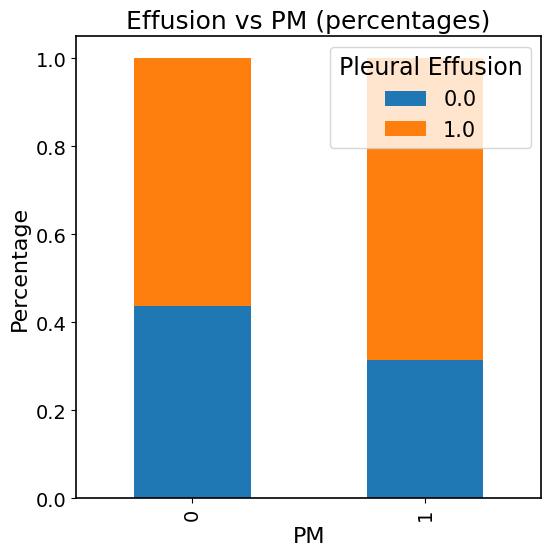

In [18]:
# Plot percentages
percentages.plot(kind='bar', stacked=True, figsize=(6, 6))
plt.title("Effusion vs PM (percentages)")
plt.xlabel("PM")
plt.ylabel("Percentage")
plt.legend(title="Pleural Effusion", loc='upper right')
plt.show()

In [19]:
# Calculate oevralp between samples from my datset with Support Devices = 1 and Ninas dataset with PM = 1, regardless of effusion status
my_support_devices_1 = clean_df[clean_df["Support Devices"] == 1]
nina_pm_1 = clean_df[clean_df["PM"] == 1]
overlap = pd.merge(my_support_devices_1, nina_pm_1, on="Path")
print(f"Number of overlapping samples with Support Devices=1 and PM=1: {len(overlap)}")
print(f"Number of non-overlapping samples with Support Devices=1 and PM=1: {len(nina_pm_1) - len(overlap)}")

Number of overlapping samples with Support Devices=1 and PM=1: 718
Number of non-overlapping samples with Support Devices=1 and PM=1: 181


In [20]:
print("Size of chexpert data:", len(chexpert_data))


Size of chexpert data: 223414


In [21]:
effusion_support_counts

NameError: name 'effusion_support_counts' is not defined

In [ ]:
# Plotm x axis Effusion and hue Support Devices
effusion_support_counts.transpose().plot(kind='bar', stacked=True, figsize=(6, 6))
plt.title("Effusion vs Support Devices (percentages)")
plt.xlabel("Support Devices")
plt.ylabel("Percentage")
plt.legend(title="Pleural Effusion", loc='upper right')
plt.show()

In [ ]:
effusion_support_counts = (
    chexpert_data
    .groupby("Pleural Effusion")["Support Devices"]
    .value_counts(normalize=True)
    .unstack()
)

# Drop rows with NaN values a
effusion_support_counts = effusion_support_counts.dropna()

# Drop -1 values from the index
effusion_support_counts = effusion_support_counts[effusion_support_counts.index != -1]  

#Print ammount of sample after dropping NaN and -1 values
print(effusion_support_counts)



In [ ]:
effusion_support_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(6, 6)
)

plt.title("Support Devices given Effusion (percentages)")
plt.xlabel("Pleural Effusion")
plt.ylabel("Percentage")
plt.legend(title="Support Devices", loc='upper right')
plt.show()

# Look at out C0 train and validation set

In [ ]:
c0_train_split = pd.read_csv("/zhome/d0/a/221493/thesis/results/C0_custom/effusion/train_c0_effusion.csv")
c0_val_split = pd.read_csv("/zhome/d0/a/221493/thesis/results/C0_custom/effusion/val_c0_effusion.csv")

In [ ]:
c0_train_split

In [ ]:
# Select columns: Path, Pleural Effusion, Support Devices
c0_train_split_col = c0_train_split[["path", "true", "pred" ]]
print(c0_train_split_col.head())

In [ ]:
# Take the original dataset chexpert_data and merge with c0_train_split_col on Path,we only want "Support Devices" from the original dataset
c0_train_merged = pd.merge(c0_train_split_col, chexpert_data[["Path", "Support Devices"]], left_on=c0_train_split_col["path"].apply(lambda x: x.replace("CheXpert-v1.0-small/train/", "")), right_on=chexpert_data["Path"].apply(lambda x: x.replace("CheXpert-v1.0-small/train/", "")), how="left")
print(c0_train_merged.head())

In [ ]:
c0_train_merged
# Filetr out nan
c0_train_merged_filtered = c0_train_merged[c0_train_merged["Support Devices"] != "nan"]
# FIlter out -1
c0_train_merged_filtered = c0_train_merged[c0_train_merged["Support Devices"] != "-1"]

print(c0_train_merged_filtered.head())

print("Size of c0_train_merged_filtered:", len(c0_train_merged_filtered))

In [ ]:


# Plot distribution of Support Devices in c0_train_merged
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.countplot(data=c0_train_merged_filtered, x="Support Devices", ax=axes[0])
axes[0].set_title("Support Devices Distribution in C0 Train Set")
axes[0].set_xlabel("Support Devices")
axes[0].set_ylabel("Count")
sns.countplot(data=c0_train_merged_filtered, x="Support Devices", ax=axes[1])
axes[1].set_title("Support Devices Distribution in C0 Train Set")
axes[1].set_xlabel("Support Devices")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# Filter nan values from Support Devices 

